In [1]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import tifffile
from scipy.ndimage import zoom, sobel

In [2]:
def generate_3d_biological_sample(grid_size, dx, thickness, num_slices, num_cells=2000):
    """
    Simulates a 3D biological sample containing spherical 'cells'.
    Returns a 3D array of refractive index variations (delta_n).
    """
    print(f"Generating 3D sample: {thickness}um thick, {num_slices} slices...")
    sample_vol = np.zeros((grid_size, grid_size, num_slices))
    
    # Cell parameters
    cell_radius_um = 5.0  
    cell_radius_px = int(cell_radius_um / dx)
    
    # Place random cells in the volume
    for _ in range(num_cells):
        cx = np.random.randint(cell_radius_px, grid_size - cell_radius_px)
        cy = np.random.randint(cell_radius_px, grid_size - cell_radius_px)
        cz = np.random.randint(0, num_slices)
        
        # Draw a sphere
        for x in range(cx - cell_radius_px, cx + cell_radius_px + 1):
            for y in range(cy - cell_radius_px, cy + cell_radius_px + 1):
                for z in range(max(0, cz - cell_radius_px), min(num_slices, cz + cell_radius_px + 1)):
                    if (x-cx)**2 + (y-cy)**2 + (z-cz)**2 <= cell_radius_px**2:
                        # Add biological refractive index perturbation (e.g., cell organelles)
                        sample_vol[x, y, z] = 0.04 * np.random.normal(1.0, 0.1) 
                        
    return sample_vol

N=512
dx = 2.56
sample_thickness = 100
num_slices = 20
sample_3d = generate_3d_biological_sample(N, dx, sample_thickness, num_slices)

Generating 3D sample: 100um thick, 20 slices...


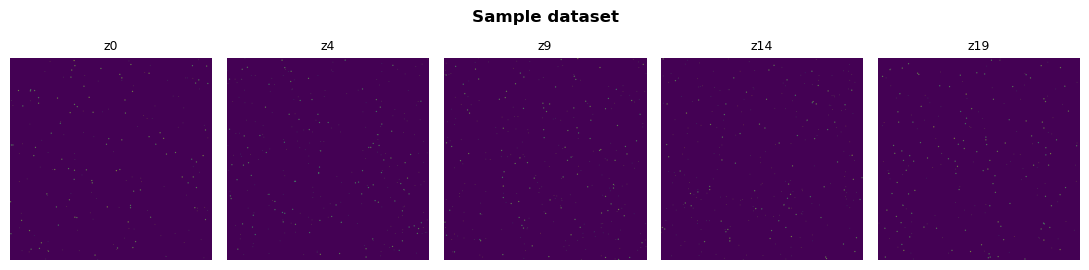

In [3]:
n_show = min(5, num_slices)
fig, axes = plt.subplots(1, n_show, figsize=(2.2*n_show,2.8 ))
for i, ax in enumerate(axes):
    idx = int(i * (num_slices - 1) / max(n_show - 1, 1))
    ax.imshow(sample_3d[:,:,idx], cmap='viridis')
    ax.set_title(f"z{idx}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample dataset", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

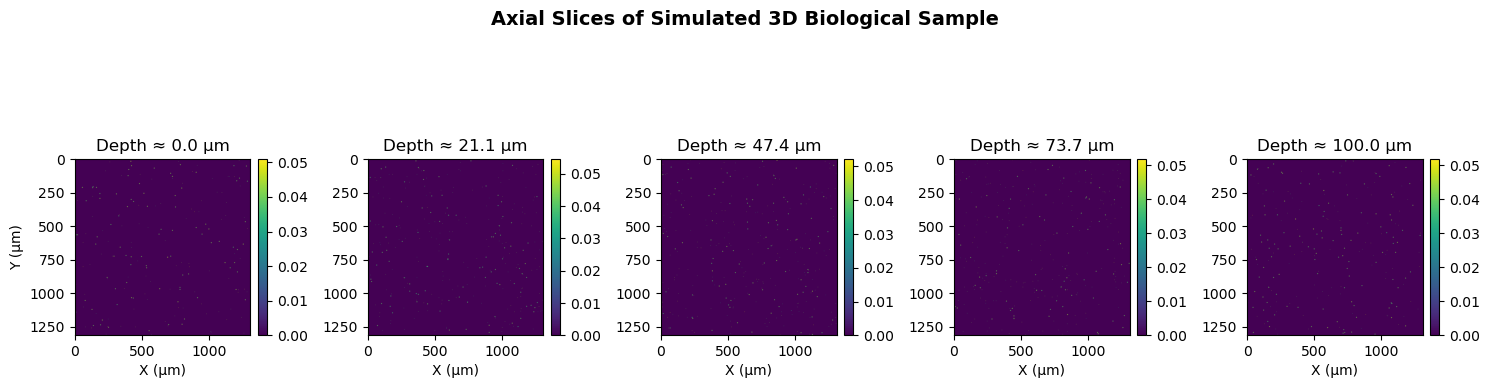

In [4]:
# Visualisation
# Select 5 evenly spaced slices from the volume to plot
slices_to_plot = np.linspace(0, num_slices - 1, 5, dtype=int)

fig, axs = plt.subplots(1, len(slices_to_plot), figsize=(15, 4))
fig.suptitle('Axial Slices of Simulated 3D Biological Sample', fontweight='bold', fontsize=14, y=1.05)

for i, slice_idx in enumerate(slices_to_plot):
    ax = axs[i]
    
    # Extract the 2D slice
    slice_2d = sample_3d[:, :, slice_idx]
    
    # Plot using an extent to show actual micrometers instead of just pixel indices
    extent_um = [0, N * dx, N * dx, 0]
    im = ax.imshow(slice_2d, cmap='viridis', extent=extent_um)
    
    # Calculate actual depth for the title
    z_depth = (slice_idx / max(1, num_slices - 1)) * sample_thickness
    ax.set_title(f'Depth ≈ {z_depth:.1f} µm')
    ax.set_xlabel('X (µm)')
    
    if i == 0:
        ax.set_ylabel('Y (µm)')
        
    # Add colorbar to each subplot to track refractive index perturbation
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
plt.tight_layout()
plt.show()


In [5]:
def load_real_3d_biological_sample(filepath, target_N, target_slices):
    """
    Loads a real 3D TIFF biological dataset, resamples it to our computational grid,
    and maps the intensity to refractive index perturbations.
    """

    # 1. Read the TIF volume. Assuming standard shape is (Z, Y, X)
    try:
        raw_volume = tifffile.imread(filepath)
    except Exception as e:
        raise RuntimeError(f"Failed to load TIFF file. Ensure it is a valid 3D stack. Error: {e}")
        
    print(f"Original dataset shape: {raw_volume.shape}")
    
    # Handle multi-channel data (Z, C, Y, X) by grabbing the first channel
    if raw_volume.ndim == 4:
        raw_volume = raw_volume[:, 0, :, :]
        
    orig_z, orig_y, orig_x = raw_volume.shape
    
    # 2. Calculate zoom factors to match (target_N, target_N, target_slices)
    # Transpose to (X, Y, Z) to match our ASM propagation loop coordinates
    volume_xyz = np.transpose(raw_volume, (2, 1, 0)) 
    
    zoom_x = target_N / volume_xyz.shape[0]
    zoom_y = target_N / volume_xyz.shape[1]
    zoom_z = target_slices / volume_xyz.shape[2]
    
    print(f"Resampling volume to {target_N}x{target_N}x{target_slices}...")
    # Order=1 is bilinear/trilinear interpolation (fast and geometrically accurate)
    resampled_volume = zoom(volume_xyz, (zoom_x, zoom_y, zoom_z), order=1)
    
    # 3. Map to Refractive Index Perturbation (Delta n)
    # Normalize between 0 and 1
    vol_min = np.min(resampled_volume)
    vol_max = np.max(resampled_volume)
    normalized_vol = (resampled_volume - vol_min) / (vol_max - vol_min + 1e-8)
    
    # Scale to typical biological refractive index contrast
    # Base index of water is ~1.33, cell structures can push ~1.37 (max perturbation ~0.04)
    delta_n_volume = normalized_vol * 0.04 
    
    print("Dataset successfully mapped to refractive index perturbations.")
    return delta_n_volume

Original dataset shape: (24, 800, 800)
Resampling volume to 512x512x20...
Dataset successfully mapped to refractive index perturbations.


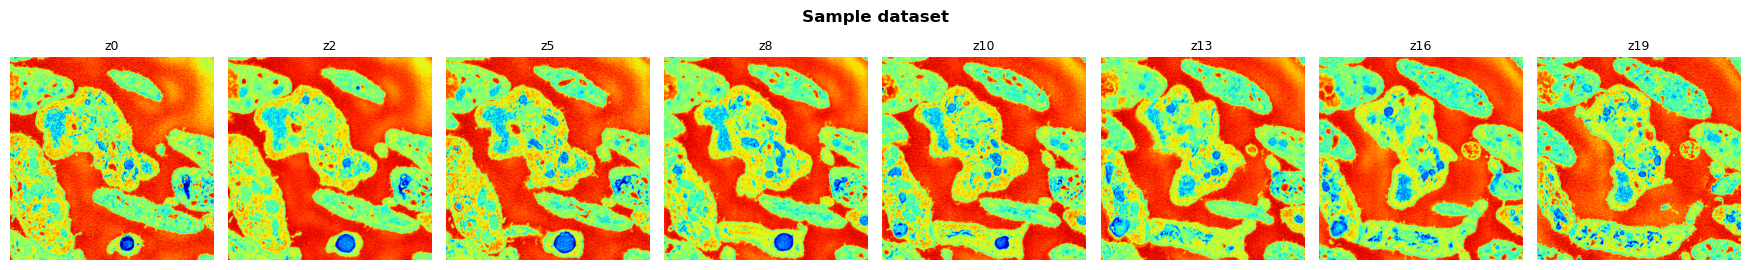

In [6]:

sample_3d = load_real_3d_biological_sample(r'C:\Users\gaura\OneDrive\Documents\GitHub\Fourier_Ptychography_Microscopy\Codes\images_and_labels_rgba\platelet-em\images\24-images.tif', N, num_slices)
n_show = min(8, num_slices)
fig, axes = plt.subplots(1, n_show, figsize=(2.2*n_show,2.8 ))
for i, ax in enumerate(axes):
    idx = int(i * (num_slices - 1) / max(n_show - 1, 1))
    ax.imshow(sample_3d[:,:,idx], cmap='jet')
    ax.set_title(f"z{idx}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample dataset", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
def angular_spectrum_prop(field, dx, z, wavelength):
    """
    Propagates a complex 2D field using the Angular Spectrum Method.
    """
    N = field.shape[0]
    k = 2 * np.pi / wavelength
    
    # Setup spatial frequencies
    fx = np.fft.fftfreq(N, d=dx)
    fx, fy = np.meshgrid(fx, fx)
    
    # Transfer function formulation
    term = 1 - (wavelength * fx)**2 - (wavelength * fy)**2
    term[term < 0] = 0 # Evanescent wave filtering
    
    H = np.exp(1j * k * z * np.sqrt(term))
    
    # Forward FFT -> Multiply by Transfer Function -> Inverse FFT
    field_f = np.fft.fft2(field)
    return np.fft.ifft2(field_f * H)


In [8]:
def tamura_coeff(image):
    mean = np.mean(image)
    stddev = np.std(image)

    tamura = stddev/mean
    return tamura
    
def calculate_brenner_gradient(image):
    """
    Calculates the Brenner gradient for a given 2D image (intensity or amplitude).
    """
    # X-direction difference
    diff_x = image[2:, :] - image[:-2, :]
    # Y-direction difference
    diff_y = image[:, 2:] - image[:, :-2]
    
    # Sum of squared differences
    brenner = np.sum(diff_x**2) + np.sum(diff_y**2)
    return brenner

def calculate_gini_coefficient(image):
    # Flatten the image to a 1D array and ensure non-negative values
    flattened = np.abs(image.flatten())
    
    # Avoid division by zero for completely dark/empty slices
    if np.sum(flattened) == 0:
        return 0.0
        
    # Sort the values in ascending order
    sorted_array = np.sort(flattened)
    n = len(sorted_array)
    
    # Apply the efficient vectorized Gini formula:
    # G = (2 * sum(i * x_i) / (n * sum(x_i))) - (n + 1) / n
    index = np.arange(1, n + 1)
    gini = (2.0 * np.sum(index * sorted_array)) / (n * np.sum(sorted_array)) - (n + 1.0) / n
    
    return gini

def calculate_tenengrad_gradient(image, threshold=0.0):
    """
    Calculates the Tenengrad gradient (focus measure) of a 2D image slice.
    Uses Sobel operators to compute the spatial gradient magnitude.
        """
    # Calculate gradients in X and Y directions using the Sobel filter
    gx = sobel(image, axis=0, mode='reflect')
    gy = sobel(image, axis=1, mode='reflect')
    
    # Calculate the squared gradient magnitude
    gradient_mag_sq = gx**2 + gy**2
    
    # Apply noise thresholding (optional)
    if threshold > 0:
        gradient_mag_sq[gradient_mag_sq < threshold] = 0
        
    # Tenengrad score is the sum of the squared gradient magnitudes
    tenengrad_score = np.sum(gradient_mag_sq)
    
    return tenengrad_score

def calculate_amplitude_variance(image_slice):
    """
    Calculates the spatial variance of the amplitude for a 2D image slice.
    Automatically extracts amplitude if a complex optical field is passed.
    """
    if np.iscomplexobj(image_slice):
        amplitude = np.abs(image_slice)
    else:
        amplitude = image_slice
        
    return np.var(amplitude)

def calculate_squared_gradient(image_slice):
    """
    Calculates the squared magnitude of the spatial gradient for a 2D image slice.
    """
    # Calculate spatial gradients along the Y and X axes using central differences
    grad_y, grad_x = np.gradient(image_slice)
    
    # Compute the squared gradient magnitude
    squared_grad_map = grad_x**2 + grad_y**2
    squared_grad_map = np.sum(squared_grad_map)
    
    return squared_grad_map


def calculate_fourier_focus_measure(image, cutoff_ratio=0.15):
    """
    Calculates the Fourier focus measure for a given 2D image slice.
    It computes the 2D FFT and evaluates the high-frequency energy.
    """
    # 1. Compute 2D Fast Fourier Transform and shift zero-frequency to the center
    f_transform = np.fft.fft2(image)
    f_shifted = np.fft.fftshift(f_transform)
    
    # 2. Extract the magnitude spectrum
    magnitude_spectrum = np.abs(f_shifted)
    
    # 3. Create a coordinate grid to mask out the low frequencies
    h, w = image.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    
    # Calculate radial distance from the DC center
    radial_distance = np.sqrt((x - cx)**2 + (y - cy)**2)
    
    # Define the radius threshold for low frequencies
    max_radius = min(cx, cy)
    cutoff_radius = cutoff_ratio * max_radius
    
    # 4. Filter for only high-frequency components
    high_freq_mask = radial_distance > cutoff_radius
    
    # 5. The focus score is the sum of the energy (squared magnitude) of high frequencies
    focus_score = np.sum(magnitude_spectrum[high_freq_mask]**2)
    
    return focus_score

Executing Multi-Slice Forward Propagation...
Propagating 1000.0um to sensor...
Initiating Z-Sweep and Brenner Gradient calculation...
Sweep complete. Best focus found at Z = -1036.36 um (relative to sensor)


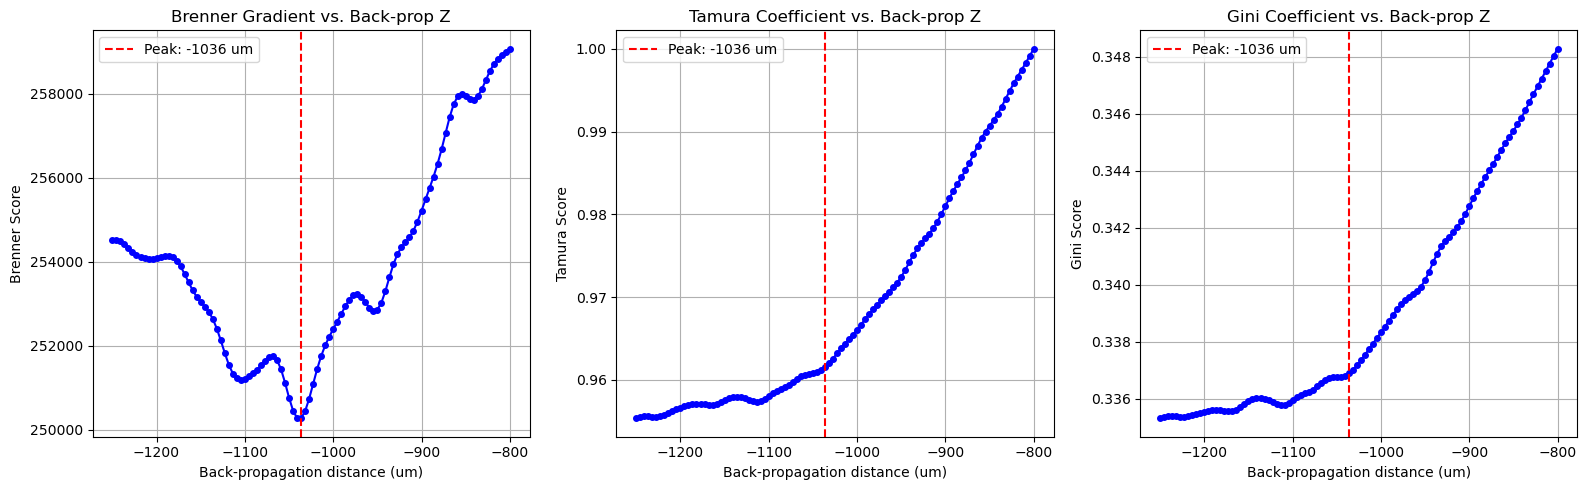

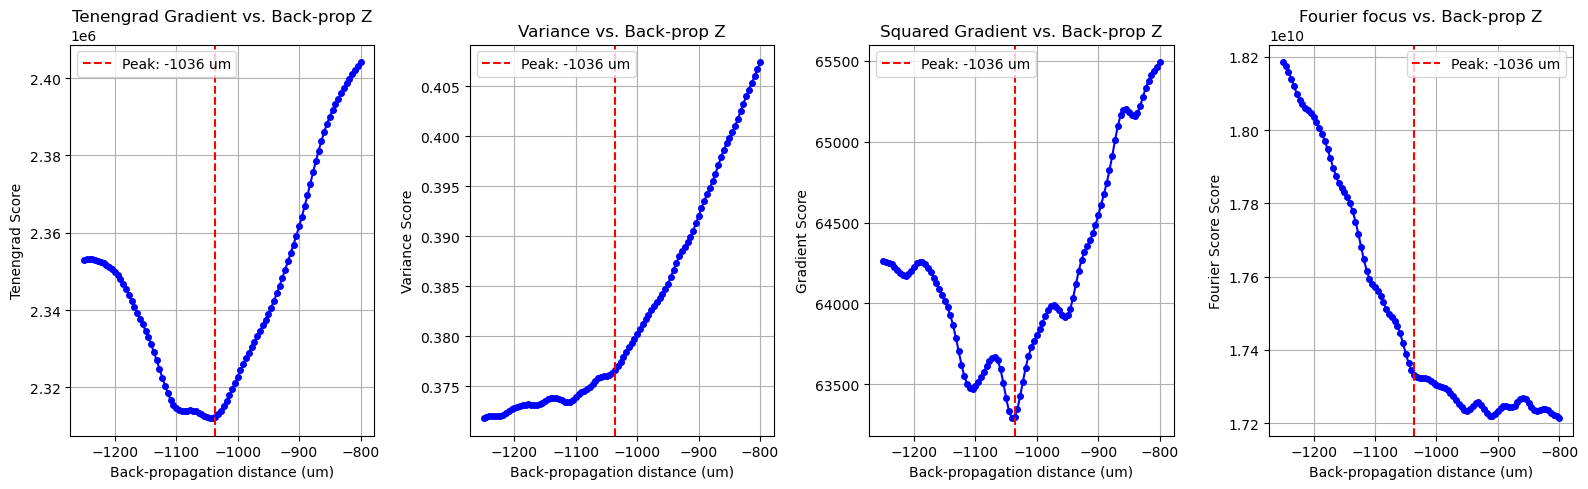

In [9]:
wavelength = 0.532  # microns (e.g., 532 nm laser)          # Grid size (N x N)

dz_slice = sample_thickness / num_slices # Distance between slices

sensor_distance = 1000.0  # 1 mm away from the sample's exit plane

# --- 1. Initialize Field ---
field = np.ones((N, N), dtype=np.complex128) # Illuminating plane wave

# --- 2. Forward Propagation (Multi-slice BPM) ---
print("Executing Multi-Slice Forward Propagation...")
for i in range(num_slices):
    # Accumulate phase shift for this slice: phi = k * delta_n * dz
    phase_shift = (2 * np.pi / wavelength) * sample_3d[:, :, i] * dz_slice
    field = field * np.exp(1j * phase_shift)
    
    # Propagate to the next slice
    if i < num_slices - 1:
        field = angular_spectrum_prop(field, dx, dz_slice, wavelength)
        
# Propagate from the exit plane to the sensor
print(f"Propagating {sensor_distance}um to sensor...")
sensor_field = angular_spectrum_prop(field, dx, sensor_distance, wavelength)

# --- 3. Sensor Recording ---
# The sensor only records intensity (losing the phase)
sensor_intensity = np.abs(sensor_field)**2

# --- 4. Z-Sweep Back-propagation ---
print("Initiating Z-Sweep and Brenner Gradient calculation...")

# We will sweep from a bit before the sensor distance up to past the sample start
# Negative Z because we are back-propagating
z_sweep_vals = np.linspace(-1250, -800, 100)
brenner_scores = []
tamura_scores = []
gini_scores = []
tenengrad_scores = []
amp_var_scores = []
squared_scores = []
fourier_scores = []
reconstructed_volumes = []

# We assume uniform phase for the backpropagation (holographic twin image will be present)
field_to_backprop = np.sqrt(sensor_intensity) 

for z_back in z_sweep_vals:
    recon_field = angular_spectrum_prop(field_to_backprop, dx, z_back, wavelength)
    recon_amp = np.abs(recon_field)

    t_score = tamura_coeff(recon_amp**2)
    tamura_scores.append(t_score)
    b_score = calculate_brenner_gradient(recon_amp**2)
    brenner_scores.append(b_score)
    g_score = calculate_gini_coefficient(recon_amp**2)
    gini_scores.append(g_score)
    tn_score = calculate_tenengrad_gradient(recon_amp**2)
    tenengrad_scores.append(tn_score)
    amp_score = calculate_amplitude_variance(recon_amp**2)
    amp_var_scores.append(amp_score)
    s_score = calculate_squared_gradient(recon_amp**2)
    squared_scores.append(s_score) 
    f_score = calculate_fourier_focus_measure(recon_amp**2)
    fourier_scores.append(f_score)
    reconstructed_volumes.append(recon_amp)

tamura_scores = np.array(tamura_scores)/(np.max(tamura_scores))
brenner_scores = np.array(brenner_scores)
gini_scores = np.array(gini_scores)
tenengrad_scores = np.array(tenengrad_scores)
amp_var_scores = np.array(amp_var_scores)
squared_scores = np.array(squared_scores)
fourier_scores = np.array(fourier_scores)
best_z_idx = np.argmin(brenner_scores)
best_z = z_sweep_vals[best_z_idx]

print(f"Sweep complete. Best focus found at Z = {best_z:.2f} um (relative to sensor)")

# --- 5. Visualization ---
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Sensor Intensity
axs[0].plot(z_sweep_vals, brenner_scores, 'b-o', markersize=4)
axs[0].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[0].set_title('Brenner Gradient vs. Back-prop Z')
axs[0].set_xlabel('Back-propagation distance (um)')
axs[0].set_ylabel('Brenner Score')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Brenner Gradient Curve
axs[1].plot(z_sweep_vals, tamura_scores, 'b-o', markersize=4)
axs[1].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[1].set_title('Tamura Coefficient vs. Back-prop Z')
axs[1].set_xlabel('Back-propagation distance (um)')
axs[1].set_ylabel('Tamura Score')
axs[1].legend()
axs[1].grid(True)

# Plot 3: Best Focused Reconstruction
axs[2].plot(z_sweep_vals, gini_scores, 'b-o', markersize=4)
axs[2].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[2].set_title('Gini Coefficient vs. Back-prop Z')
axs[2].set_xlabel('Back-propagation distance (um)')
axs[2].set_ylabel('Gini Score')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


# --- 5. Visualization ---
fig, axs = plt.subplots(1, 4, figsize=(16, 5))

# Plot 1: Sensor Intensity
axs[0].plot(z_sweep_vals, tenengrad_scores, 'b-o', markersize=4)
axs[0].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[0].set_title('Tenengrad Gradient vs. Back-prop Z')
axs[0].set_xlabel('Back-propagation distance (um)')
axs[0].set_ylabel('Tenengrad Score')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Brenner Gradient Curve
axs[1].plot(z_sweep_vals, amp_var_scores, 'b-o', markersize=4)
axs[1].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[1].set_title('Variance vs. Back-prop Z')
axs[1].set_xlabel('Back-propagation distance (um)')
axs[1].set_ylabel('Variance Score')
axs[1].legend()
axs[1].grid(True)

# Plot 3: Best Focused Reconstruction
axs[2].plot(z_sweep_vals, squared_scores, 'b-o', markersize=4)
axs[2].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[2].set_title('Squared Gradient vs. Back-prop Z')
axs[2].set_xlabel('Back-propagation distance (um)')
axs[2].set_ylabel('Gradient Score')
axs[2].legend()
axs[2].grid(True)

axs[3].plot(z_sweep_vals, fourier_scores, 'b-o', markersize=4)
axs[3].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
axs[3].set_title('Fourier focus vs. Back-prop Z')
axs[3].set_xlabel('Back-propagation distance (um)')
axs[3].set_ylabel('Fourier Score Score')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()